# Proyecto Final - Ciencia de datos

## Parte 1

Carga la base de datos y limpieza de datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para visualizaciones
sns.set_theme(style="darkgrid")

try:
    df = pd.read_csv('../BaseDatos/train.csv')
    print("Dataset cargado exitosamente.")
except FileNotFoundError:
    print("Error: No se encontró el archivo .csv. Por favor, cárgalo en el entorno.")

num_cols = ["log_price", "accommodates", "bathrooms", "bedrooms",
            "beds", "number_of_reviews", "review_scores_rating"]
 
df_clean = df[num_cols].copy()

for col in df_clean.columns:
    missing = df_clean[col].isna().sum()
    if missing > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"  '{col}': {missing} valores faltantes → imputados con mediana ({median_val:.2f})")

antes = len(df_clean)
for col in df_clean.columns:
    Q1 = df_clean[col].quantile(0.01)
    Q3 = df_clean[col].quantile(0.99)
    df_clean = df_clean[(df_clean[col] >= Q1) & (df_clean[col] <= Q3)]
 
despues = len(df_clean)
print(f"\nFilas eliminadas por outliers extremos (<1% y >99%): {antes - despues}")
print(f"Shape final limpio: {df_clean.shape}")

Dataset cargado exitosamente.
  'bathrooms': 200 valores faltantes → imputados con mediana (1.00)
  'bedrooms': 91 valores faltantes → imputados con mediana (1.00)
  'beds': 131 valores faltantes → imputados con mediana (1.00)
  'review_scores_rating': 16722 valores faltantes → imputados con mediana (96.00)

Filas eliminadas por outliers extremos (<1% y >99%): 5175
Shape final limpio: (68936, 7)


## Parte 2

### Análisis Descriptivo


In [9]:
depend = "log_price"
independ = ["accommodates", "bathrooms", "bedrooms",
            "beds", "number_of_reviews", "review_scores_rating"]
 
print(f"Variable DEPENDIENTE : {depend}")
print(f"Variables INDEPENDIENTES: {independ}")
 
X = df_clean[independ]
y = df_clean[depend]

Variable DEPENDIENTE : log_price
Variables INDEPENDIENTES: ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']


## Análisis de correlación y Selección de características

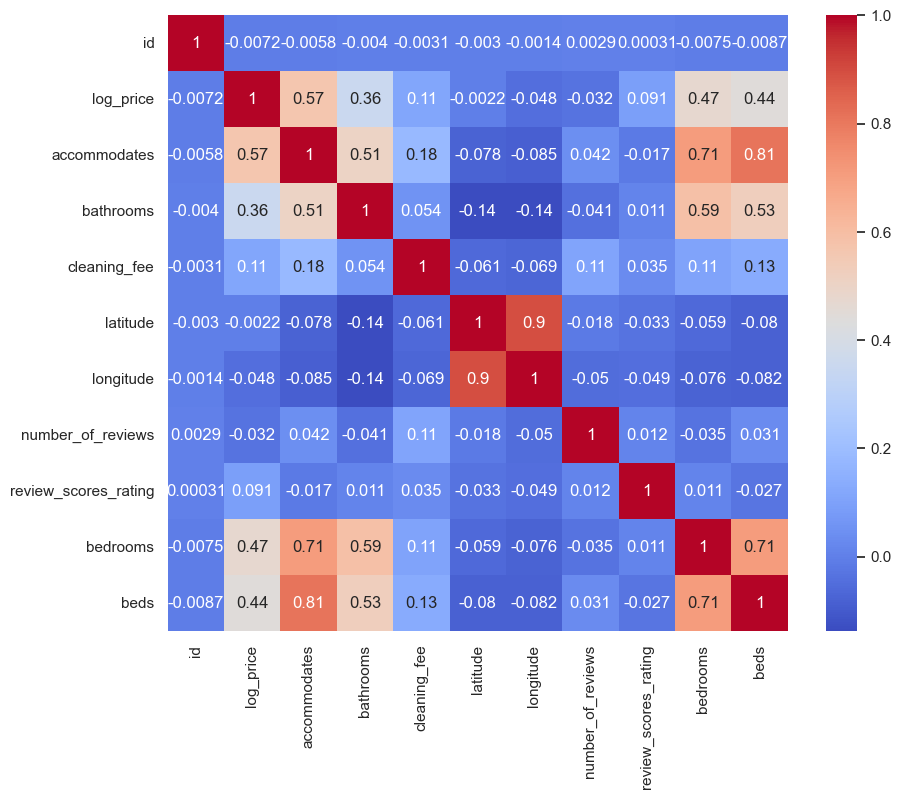

In [11]:
# Mapa de calor de correlación
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()


Las correlaciones con log_price muestran que accommodates (0.58), beds (0.48) y bedrooms (0.43) son las más relevantes. number_of_reviews casi no aporta (0.003).